<a href="https://colab.research.google.com/github/th1rteen0/brain_tumor_classification/blob/main/binary_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    print(f'Uploaded file: {filename}')

Saving dataset.zip to dataset.zip
Uploaded file: dataset.zip
['__MACOSX', 'binary_data']
['no', '.DS_Store', 'yes']


In [ ]:
import zipfile
import os

zip_path = 'dataset.zip'
extract_path = 'dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

data_folder = os.path.join(extract_path, 'dataset')
print(os.listdir(data_folder))  # should show your class folders

['__MACOSX', 'dataset']
['no', '.DS_Store', 'yes']


In [ ]:
import tensorflow as tf
import os
from matplotlib import pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy
from tensorflow.keras.models import load_model
from collections import Counter
import numpy as np
import os
from PIL import Image

print("Imports successful")

Imports successful


In [ ]:
# 1. data loading and preprocessing
# parameters
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
SEED = 123
EPOCHS = 30

train_data = tf.keras.utils.image_dataset_from_directory(
    data_folder,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

val_data = tf.keras.utils.image_dataset_from_directory(
    data_folder,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

Found 5712 files belonging to 2 classes.
Using 4570 files for training.
Found 5712 files belonging to 2 classes.
Using 1142 files for validation.


In [ ]:
# preprocessing steps

# augmentation + normalization
# normalization -- # scales pixel values from 0-255 to 0-1 for faster and more stable training
# augmentation -- creates variations of images to prevent overfitting and improve generalization (flips, rotations, cropping, zooming, etc)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomContrast(0.2)
])

train_data = train_data.map(lambda x, y: (data_augmentation(x, training=True)/255.0, y))
val_data = val_data.map(lambda x, y: (x/255.0, y))

In [ ]:
# 2. model design and training
# build CNN model
model = Sequential()

# this layer looks at small parts of an image at a time and learns to recognize patterns like edges, corners, or textures.
# more layers = model starts understanding more complex shapes (like the outline of a tumor)
model.add(Conv2D(16, (3,3), 1, activation='relu', input_shape=(256,256,3)))

# this layer reduces the size of the image after each convolution. it keeps the most important information and
# throws away extra details. it makes the model faster and helps it focus on the main features
model.add(MaxPooling2D())

# this layer helps prevent overfitting (memorizing training data). during training, it randomly drops units/turn off neurons
# so the model learns more general patterns instead of memorizing the images
model.add(Dropout(0.2))  # dropout layer after the convolutional layers

model.add(Conv2D(32, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())
model.add(Dropout(0.2))

model.add(Conv2D(16, (3,3), 1, activation='relu', name="last_conv"))
model.add(MaxPooling2D())
model.add(Dropout(0.2))

# convert 2D feature maps to 1D vector
model.add(Flatten())
# layers that make the final decisions. each neuron connects to all the others in the previous layer
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid')) # binary classification

# compile model
model.compile(
    optimizer='adam',
    loss=tf.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# early stopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,  # stop after 3 epochs of no improvement
    restore_best_weights=True  # restore the weights from the best epoch
)

# tensorboard logging
log_directory = 'logs'
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_directory)

In [ ]:
# train the model
hist = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[early_stopping, tensorboard_callback],
)

Epoch 1/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 75s 477ms/step - accuracy: 0.6793 - loss: 0.8118 - val_accuracy: 0.8713 - val_loss: 0.3220
Epoch 2/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 59s 414ms/step - accuracy: 0.8825 - loss: 0.3141 - val_accuracy: 0.9186 - val_loss: 0.2201
Epoch 3/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 59s 409ms/step - accuracy: 0.9213 - loss: 0.2206 - val_accuracy: 0.9046 - val_loss: 0.2230
Epoch 4/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 59s 415ms/step - accuracy: 0.9266 - loss: 0.2015 - val_accuracy: 0.9203 - val_loss: 0.1932
Epoch 5/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 60s 416ms/step - accuracy: 0.9467 - loss: 0.1589 - val_accuracy: 0.9527 - val_loss: 0.1660
Epoch 6/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 60s 415ms/step - accuracy: 0.9535 - loss: 0.1488 - val_accuracy: 0.9571 - val_loss: 0.1551
Epoch 7/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 58s 406ms/step - accuracy: 0.9571 - loss: 0.1295 - val_accuracy: 0.9501 - val_loss: 0.1482
Epoch 8/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 60s 415ms/step - accuracy: 0.9568 - loss: 0

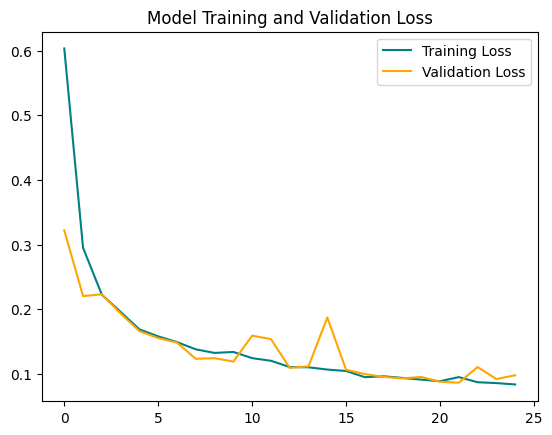

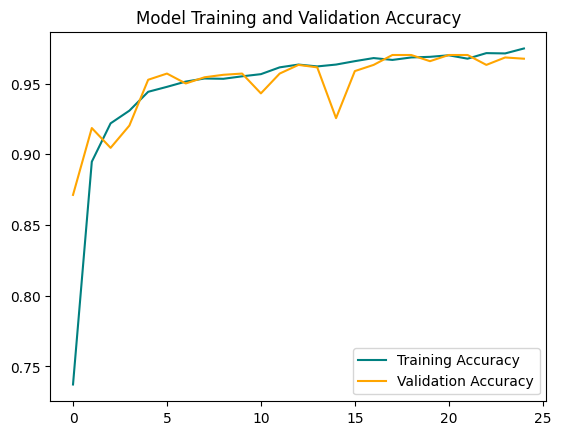

In [ ]:
# 3. model explainability
# visualize loss
plt.figure()
plt.plot(hist.history['loss'], label='Training Loss', color='teal')
plt.plot(hist.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Training and Validation Loss')
plt.legend()
plt.show()

# visualize accuracy
plt.figure()
plt.plot(hist.history['accuracy'], label='Training Accuracy', color='teal')
plt.plot(hist.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Training and Validation Accuracy')
plt.legend()
plt.show()

In [ ]:
# evaluate
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

for x, y in val_data: # use validation data as test
    y_pred = model.predict(x)
    pre.update_state(y, y_pred)
    re.update_state(y, y_pred)
    acc.update_state(y, y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━

In [ ]:
print("Precision:", pre.result())
print("Recall:", re.result())
print("Accuracy:", acc.result())

model.evaluate(train_data)
model.evaluate(val_data)

Precision: tf.Tensor(0.98805255, shape=(), dtype=float32)
Recall: tf.Tensor(0.9717979, shape=(), dtype=float32)
Accuracy: tf.Tensor(0.97022766, shape=(), dtype=float32)
143/143 ━━━━━━━━━━━━━━━━━━━━ 61s 423ms/step - accuracy: 0.9812 - loss: 0.0622
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9638 - loss: 0.1044


[0.08609148114919662, 0.9702276587486267]

In [ ]:
# export model for web app

from google.colab import files

# save model
model.save('model.keras')

# download to laptop
files.download('model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>